In [137]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [138]:
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

In [139]:
train_data = train_datagen.flow_from_directory('dataset/', target_size=(64,64),
batch_size=16, class_mode='binary', subset='training')

Found 70 images belonging to 2 classes.


In [140]:
val_data = train_datagen.flow_from_directory('dataset/', target_size=(64,64),
batch_size=16, class_mode='binary', subset='validation')

Found 17 images belonging to 2 classes.


In [141]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Input(shape=(64, 64, 3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [142]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [143]:
history = model.fit(train_data, validation_data=val_data, epochs=30)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 783ms/step - accuracy: 0.5000 - loss: 0.8177 - val_accuracy: 0.4706 - val_loss: 0.6848
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 624ms/step - accuracy: 0.4714 - loss: 0.6841 - val_accuracy: 0.4706 - val_loss: 0.6801
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 610ms/step - accuracy: 0.7286 - loss: 0.6354 - val_accuracy: 0.5294 - val_loss: 0.6358
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 610ms/step - accuracy: 0.8429 - loss: 0.4521 - val_accuracy: 0.5294 - val_loss: 0.5785
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 620ms/step - accuracy: 0.9286 - loss: 0.2422 - val_accuracy: 0.8824 - val_loss: 0.3535
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 626ms/step - accuracy: 1.0000 - loss: 0.0947 - val_accuracy: 0.5882 - val_loss: 0.6515
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 612ms/step - accuracy: 1.0000 - loss: 0.0440 - val_accuracy: 1.0000 - val_loss: 0.1231
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 628ms/step - accuracy: 1.0000 - loss: 0.0087 - val_accuracy: 0.7647 - val_loss:

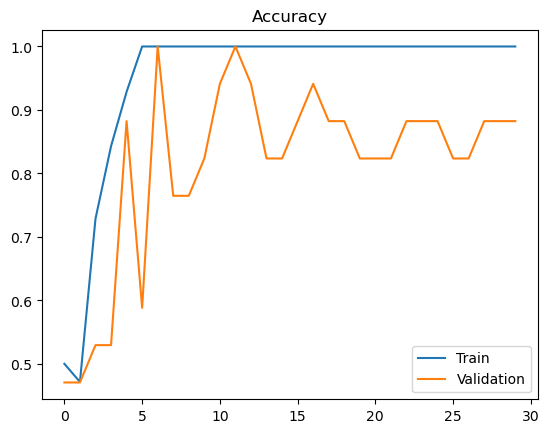

In [144]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

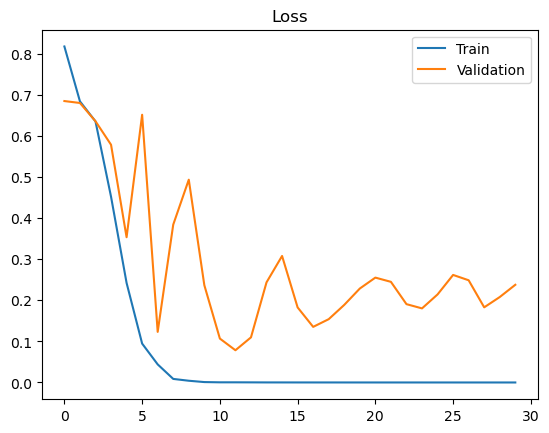

In [145]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train","Validation"])
plt.show()

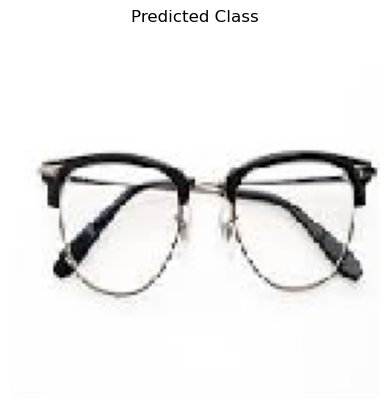

In [146]:
plt.imshow(img[0])
plt.title("Predicted Class")
plt.axis('off')
plt.show()

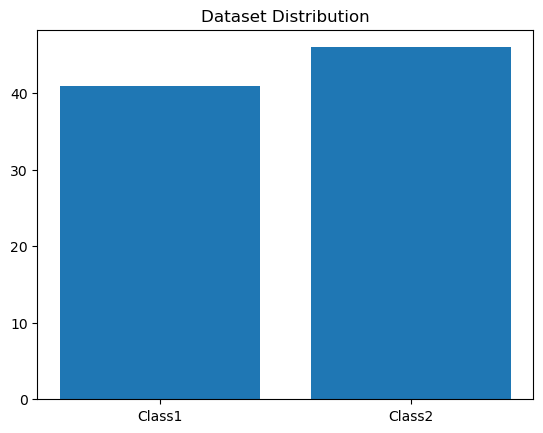

In [147]:
import os
count1 = len(os.listdir('dataset/class1'))
count2 = len(os.listdir('dataset/class2'))
plt.bar(['Class1','Class2'], [count1, count2])
plt.title("Dataset Distribution")
plt.show()

In [148]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img('img.jpg', target_size=(64, 64))
img = image.img_to_array(img)
img = img / 255.0
img = np.expand_dims(img, axis=0)

print(img.shape)

(1, 64, 64, 3)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


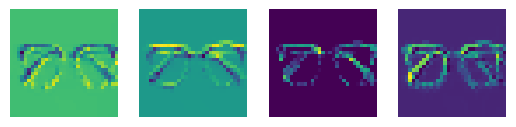

In [149]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
import matplotlib.pyplot as plt

input_tensor = Input(shape=(64, 64, 3))

x = model.layers[0](input_tensor)
x = model.layers[1](x)

activation_model = Model(inputs=input_tensor, outputs=x)
activations = activation_model.predict(img)

for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(activations[0, :, :, i])
    plt.axis('off')
plt.show()